## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings


warnings.filterwarnings('ignore')

In [77]:
sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#dddddd'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PALETTE = {
    'primary': '#1d3557',   
    'secondary': '#457b9d',   
    'accent': '#e63946',      
    'light': '#f1faee',       
    'highlight': '#a8dadc'    
}
sns.set_palette([PALETTE['primary'], PALETTE['secondary'], PALETTE['highlight'], PALETTE['accent']])

## 1. Load and Prepare the Data

In [56]:
df = pd.read_csv("../data/MachineLearningRating_v3.txt", sep="|")

## 2. Initial Inspection

In [3]:
df.shape

(1000098, 52)

In [14]:
df.head(1).T

,0
UnderwrittenCoverID,145249
PolicyID,12827
TransactionMonth,2015-03-01 00:00:00
IsVATRegistered,True
Citizenship,
LegalType,Close Corporation
Title,Mr
Language,English
Bank,First National Bank
AccountType,Current account


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  object 
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  object 
 5   LegalType                 1000098 non-null  object 
 6   Title                     1000098 non-null  object 
 7   Language                  1000098 non-null  object 
 8   Bank                      854137 non-null   object 
 9   AccountType               959866 non-null   object 
 10  MaritalStatus             991839 non-null   object 
 11  Gender                    990562 non-null   object 
 12  Country                   1000098 non-null  object 
 13  Province                  1

### Convert Date Columns

In [57]:
df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'])
df['VehicleIntroDate'] = pd.to_datetime(
    df['VehicleIntroDate'],
    errors='coerce'
)

## 3. Feature Engineering

### Loss Ratio

In [58]:
df['LossRatio'] = np.where(
    df['TotalPremium'] > 0,
    df['TotalClaims'] / df['TotalPremium'],
    0
)

### Margin

In [59]:
df['Margin'] = df['TotalPremium'] - df['TotalClaims']

## 4. Data Summarization

In [11]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
UnderwrittenCoverID,1000098.0,104817.546075,1.0,55143.0,94083.0,139190.0,301175.0,63293.708455
PolicyID,1000098.0,7956.68245,14.0,4500.0,7071.0,11077.0,23246.0,5290.03851
TransactionMonth,1000098,2015-02-28 10:49:29.147423744,2013-10-01 00:00:00,2015-01-01 00:00:00,2015-04-01 00:00:00,2015-06-01 00:00:00,2015-08-01 00:00:00,NaN
PostalCode,1000098.0,3020.600887,1.0,827.0,2000.0,4180.0,9870.0,2649.854413
mmcode,999546.0,54877704.020474,4041200.0,60056925.0,60058415.0,60058418.0,65065350.0,13603805.343562
RegistrationYear,1000098.0,2010.225371,1987.0,2008.0,2011.0,2013.0,2015.0,3.261391
Cylinders,999546.0,4.046642,0.0,4.0,4.0,4.0,10.0,0.29402
cubiccapacity,999546.0,2466.743258,0.0,2237.0,2694.0,2694.0,12880.0,442.80064
kilowatts,999546.0,97.207919,0.0,75.0,111.0,111.0,309.0,19.393256
NumberOfDoors,999546.0,4.01925,0.0,4.0,4.0,4.0,6.0,0.468314


## 5. Data Quality Assessment

In [60]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (missing / len(df)) * 100

pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percentage
})

,Missing Values,Percentage
NumberOfVehiclesInFleet,1000098,100.000000
CrossBorder,999400,99.930207
CustomValueEstimate,779642,77.956560
Converted,641901,64.183810
WrittenOff,641901,64.183810
Rebuilt,641901,64.183810
NewVehicle,153295,15.327998
Bank,145961,14.594670
AccountType,40232,4.022806
Gender,9536,0.953507


### 1. Columns with ~100% Missing

In [61]:
df.drop(columns=['NumberOfVehiclesInFleet'], inplace=True)

> NumberOfVehiclesInFleet contained 100% missing values and therefore provided no analytical value. The feature was removed from the dataset.

### 2. Extremely Sparse Columns (>95% Missing)

In [62]:
df.drop(columns=['CrossBorder'], inplace=True)

- Too sparse
- Imputation would introduce noise
- Minimal predictive value at this stage

### 3. High Missingness but Potentially Meaningful

In [63]:
cols = ['WrittenOff', 'Rebuilt', 'Converted']

for col in cols:
    df[col] = df[col].fillna('No')

> Missing values in WrittenOff, Rebuilt, and Converted were interpreted as the absence of those vehicle conditions and imputed with "No".

In [64]:
df['CustomValueEstimate'] = df.groupby(
    ['make', 'Model']
)['CustomValueEstimate'].transform(
    lambda x: x.fillna(x.median())
)

In [65]:
df['CustomValueEstimate'].fillna(
    df['CustomValueEstimate'].median(),
    inplace=True
)

> Missing vehicle value estimates were imputed using median values within similar vehicle make/model groups to preserve realistic asset valuation patterns while minimizing distortion from extreme vehicle prices.

### 6. Handling Catagorical columns

In [66]:
df['NewVehicle'].fillna('Unknown', inplace=True)
df['Bank'].fillna('Unknown', inplace=True)
cat_cols = ['AccountType', 'Gender', 'MaritalStatus']

for col in cat_cols:
    df[col] = df[col].fillna('Not specified')

### 7. Vehicle Attribute Columns

In [67]:
vehicle_cols = [
    'VehicleType', 'NumberOfDoors', 'VehicleIntroDate',
    'cubiccapacity', 'bodytype', 'Model',
    'Cylinders', 'kilowatts', 'make', 'mmcode'
]

df.dropna(subset=vehicle_cols, inplace=True)

### Missing column handling
> Missing-value handling was performed using a combination of deletion and business-informed imputation strategies. Features with near-complete missingness (NumberOfVehiclesInFleet, CrossBorder) were removed due to limited analytical value. Vehicle-condition indicators such as WrittenOff, Rebuilt, and Converted were imputed with "No" because missing values likely represented the absence of those conditions. Numerical vehicle valuation data (CustomValueEstimate) was imputed using grouped median values based on vehicle make and model to preserve realistic pricing distributions. Low-frequency missing vehicle attribute rows (<0.1%) were removed due to negligible impact on dataset size.

## 6. Univariate Analysis

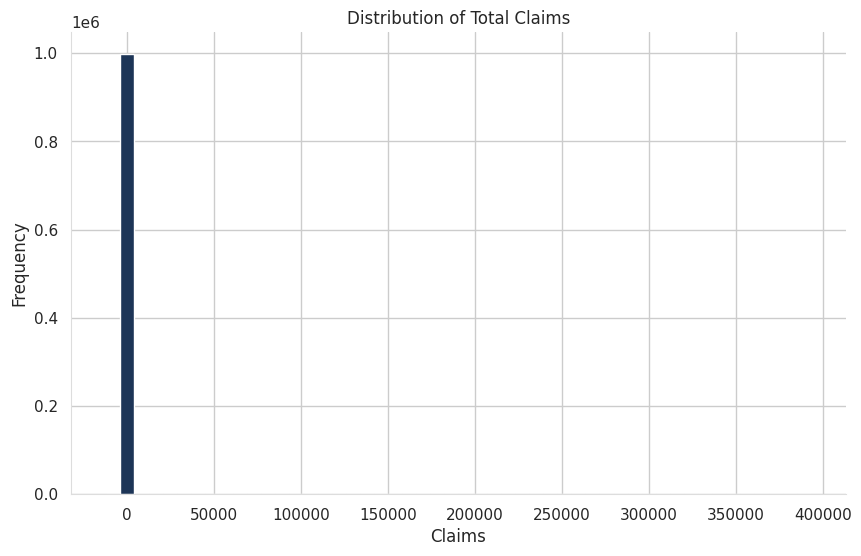

In [78]:
df['TotalClaims'].hist(bins=50)
plt.title('Distribution of Total Claims')
plt.xlabel('Claims')
plt.ylabel('Frequency')
plt.show()

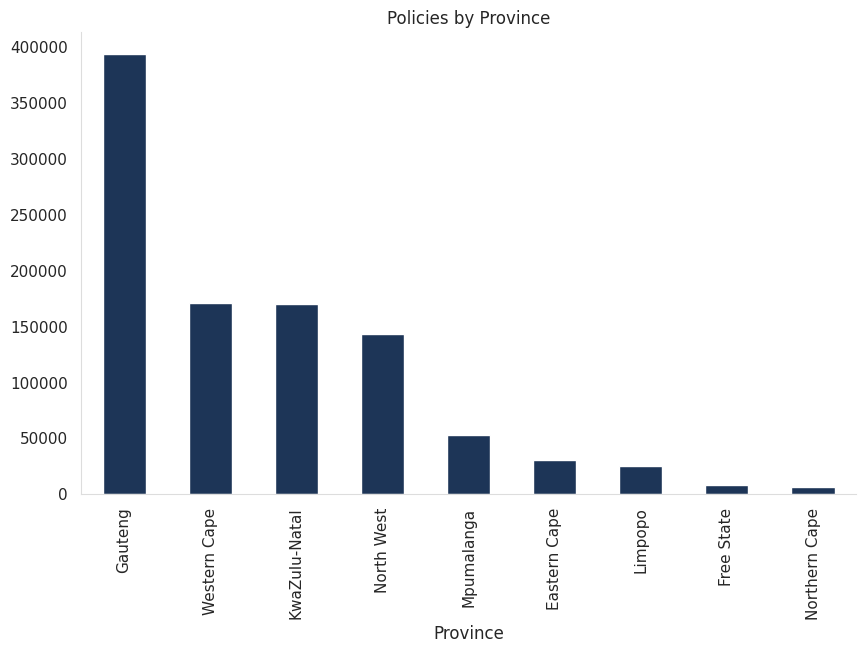

In [79]:
df['Province'].value_counts().plot(kind='bar')
plt.title('Policies by Province')
plt.show()

## 7. Bivariate / Multivariate Analysis

### Premium vs Claims scatter plot

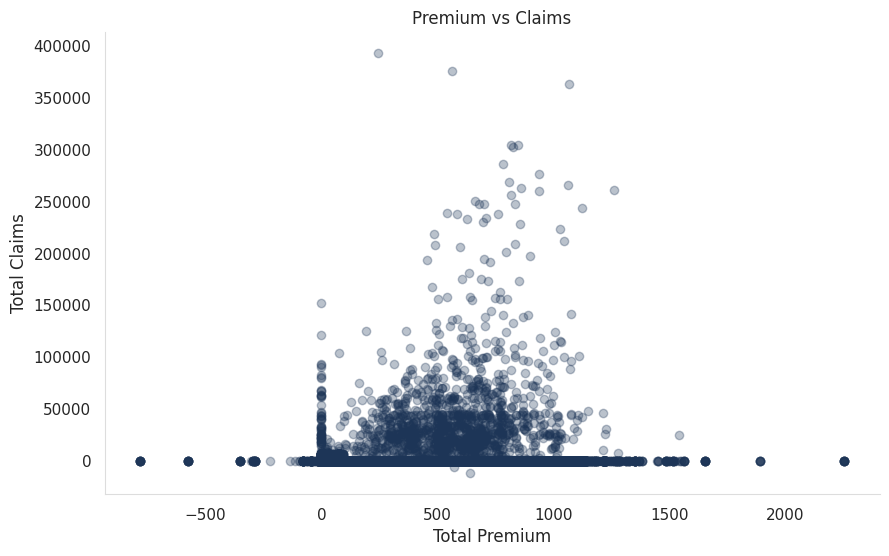

In [80]:
plt.scatter(df['TotalPremium'], df['TotalClaims'], alpha=0.3)
plt.xlabel('Total Premium')
plt.ylabel('Total Claims')
plt.title('Premium vs Claims')
plt.show()

### Correlation Matrix

In [26]:
num_cols = [
    'TotalPremium',
    'TotalClaims',
    'SumInsured',
    'CustomValueEstimate',
    'Margin',
    'LossRatio'
]

corr = df[num_cols].corr()

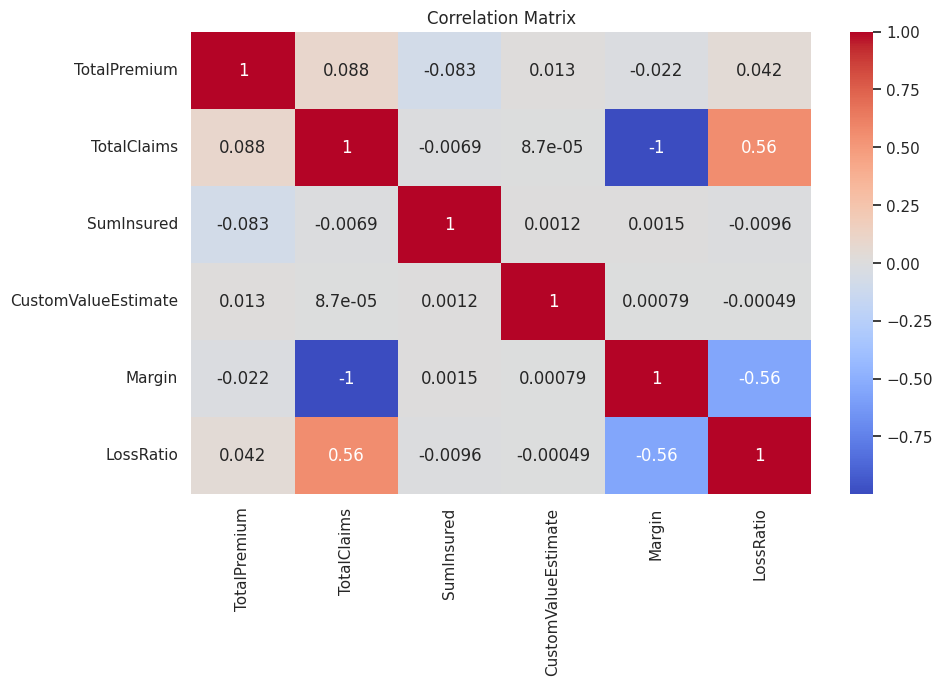

In [40]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Analysis by Postal Code

In [69]:
zipcode_analysis = df.groupby('PostalCode')[
    ['TotalPremium', 'TotalClaims', 'LossRatio']
].mean()

zipcode_analysis

,TotalPremium,TotalClaims,LossRatio
PostalCode,,,
1,51.120638,57.589092,0.176320
2,40.901700,41.589582,0.374228
4,113.947737,0.000000,0.000000
5,61.653626,207.378816,0.629011
6,50.591432,19.610447,0.061463
...,...,...,...
9781,54.553324,139.499604,0.053250
9830,131.760895,0.000000,0.000000
9868,116.042377,0.000000,0.000000


## 8. Geographic Trends

In [30]:
province_premium = df.groupby('Province')['TotalPremium'].mean()
province_claims = df.groupby('Province')['TotalClaims'].mean()
province_lr = df.groupby('Province')['LossRatio'].mean()
pd.crosstab(df['Province'], df['make'])

make,AUDI,B.A.W,BMW,C.A.M,CHERY,CHEVROLET,CITROEN,CMC,DAIHATSU,FIAT,...,PROTON,RENAULT,SAIC,SCANIA,SUZUKI,TATA,TOYOTA,TOYOTA,VOLKSWAGEN,VOLVO
Province,,,,,,,,,,,,,,,,,,,,,
Eastern Cape,0,135,0,77,0,90,0,620,0,0,...,0,0,81,0,0,0,26582,72,450,0
Free State,0,0,108,135,0,0,0,167,0,0,...,0,0,0,0,0,0,6566,0,146,0
Gauteng,6173,230,3821,8408,280,652,561,9141,0,205,...,198,90,282,0,271,100,306045,816,8775,207
KwaZulu-Natal,539,773,0,1216,0,80,0,2353,0,0,...,0,0,0,0,136,80,153241,80,3710,0
Limpopo,0,176,0,278,0,0,0,305,0,88,...,0,0,0,0,0,0,18076,0,1678,0
Mpumalanga,0,0,0,1496,0,0,0,1776,0,0,...,0,0,0,342,0,0,41589,80,1635,0
North West,371,344,4,4501,81,90,0,5800,1,0,...,0,1,170,0,1,199,108035,1,2045,1
Northern Cape,0,0,0,0,0,0,0,863,0,0,...,0,0,0,0,0,0,4928,0,108,0
Western Cape,324,502,1384,60,0,0,0,599,0,691,...,0,65,81,0,0,2,148218,117,2382,108


## 9. Outlier Detection

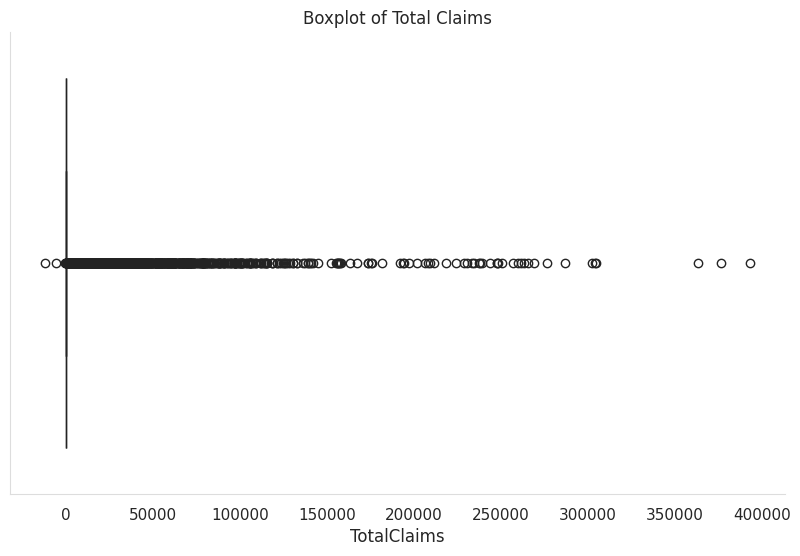

In [81]:
sns.boxplot(x=df['TotalClaims'])
plt.title('Boxplot of Total Claims')
plt.show()

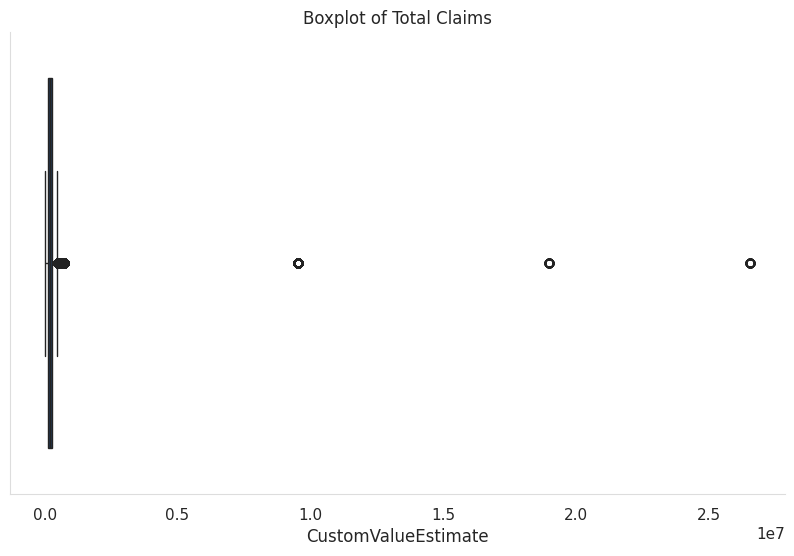

In [82]:
sns.boxplot(x=df['CustomValueEstimate'])
plt.title('Boxplot of Total Claims')
plt.show()

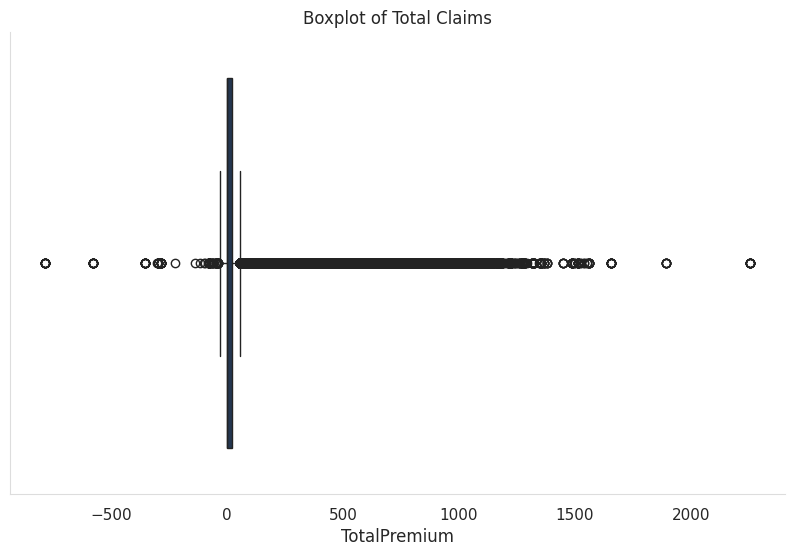

In [83]:
sns.boxplot(x=df['TotalPremium'])
plt.title('Boxplot of Total Claims')
plt.show()

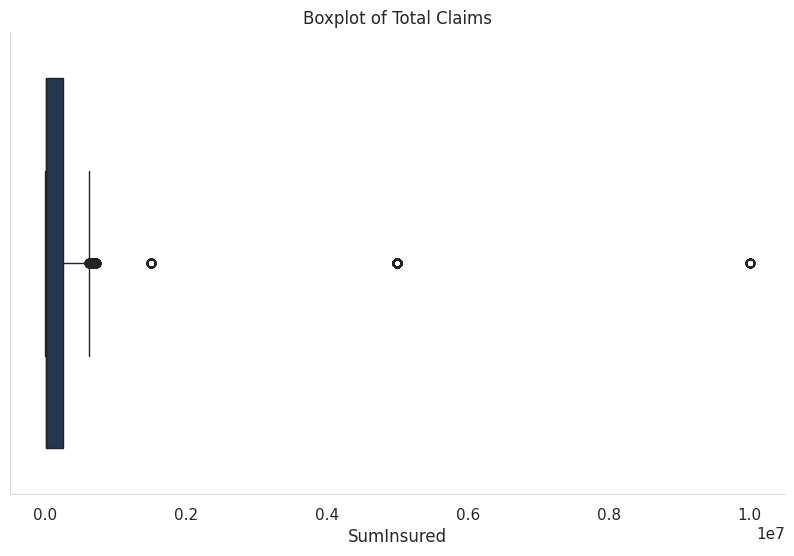

In [84]:
sns.boxplot(x=df['SumInsured'])
plt.title('Boxplot of Total Claims')
plt.show()

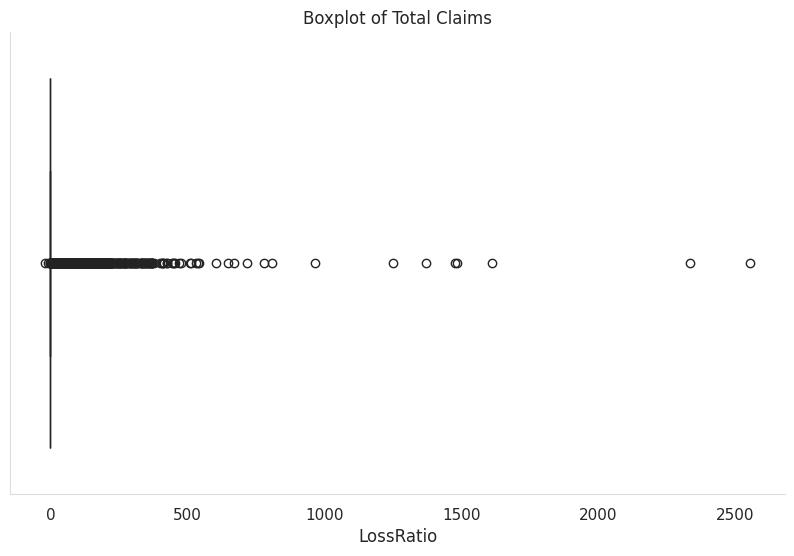

In [85]:
sns.boxplot(x=df['LossRatio'])
plt.title('Boxplot of Total Claims')
plt.show()

>Outliers were identified and investigated because they may represent high-risk policyholders or catastrophic claim events, both of which are important for actuarial pricing and segmentation.

## 1. Overall Loss Ratio for the Portfolio

In [70]:
overall_loss_ratio = (
    df['TotalClaims'].sum() /
    df['TotalPremium'].sum()
)

print(f"Overall Loss Ratio: {overall_loss_ratio:.2%}")

Overall Loss Ratio: 104.84%


### Loss Ratio by Province

In [71]:
province_lr = df.groupby('Province').agg({
    'TotalClaims': 'sum',
    'TotalPremium': 'sum'
})

province_lr['LossRatio'] = (
    province_lr['TotalClaims'] /
    province_lr['TotalPremium']
)

province_lr.sort_values('LossRatio', ascending=False)

,TotalClaims,TotalPremium,LossRatio
Province,,,
Gauteng,2.939415e+07,2.404901e+07,1.222260
KwaZulu-Natal,1.430138e+07,1.320908e+07,1.082693
Western Cape,9.833088e+06,9.244403e+06,1.063680
North West,5.920250e+06,7.490508e+06,0.790367
Mpumalanga,2.044675e+06,2.836106e+06,0.720945
Free State,3.549223e+05,5.213632e+05,0.680758
Limpopo,1.016477e+06,1.537324e+06,0.661199
Eastern Cape,1.356427e+06,2.140104e+06,0.633813
Northern Cape,8.949051e+04,3.165581e+05,0.282699


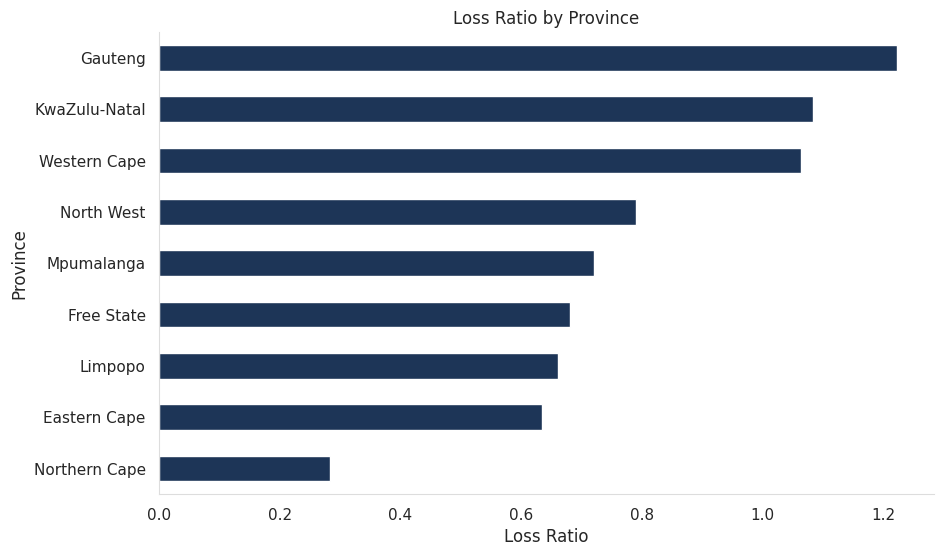

In [86]:
province_lr['LossRatio'].sort_values().plot(
    kind='barh',
    figsize=(10,6)
)
plt.title('Loss Ratio by Province')
plt.xlabel('Loss Ratio')
plt.show()

### Loss Ratio by Vehicle Type

In [73]:
vehicle_lr = df.groupby('VehicleType').agg({
    'TotalClaims': 'sum',
    'TotalPremium': 'sum'
})

vehicle_lr['LossRatio'] = (
    vehicle_lr['TotalClaims'] /
    vehicle_lr['TotalPremium']
)

vehicle_lr.sort_values('LossRatio', ascending=False)

,TotalClaims,TotalPremium,LossRatio
VehicleType,,,
Heavy Commercial,7.504746e+05,4.609479e+05,1.628112
Medium Commercial,4.119867e+06,3.922746e+06,1.050251
Passenger Vehicle,5.937207e+07,5.664202e+07,1.048198
Light Commercial,6.045250e+04,2.604975e+05,0.232066
Bus,7.996535e+03,5.824474e+04,0.137292


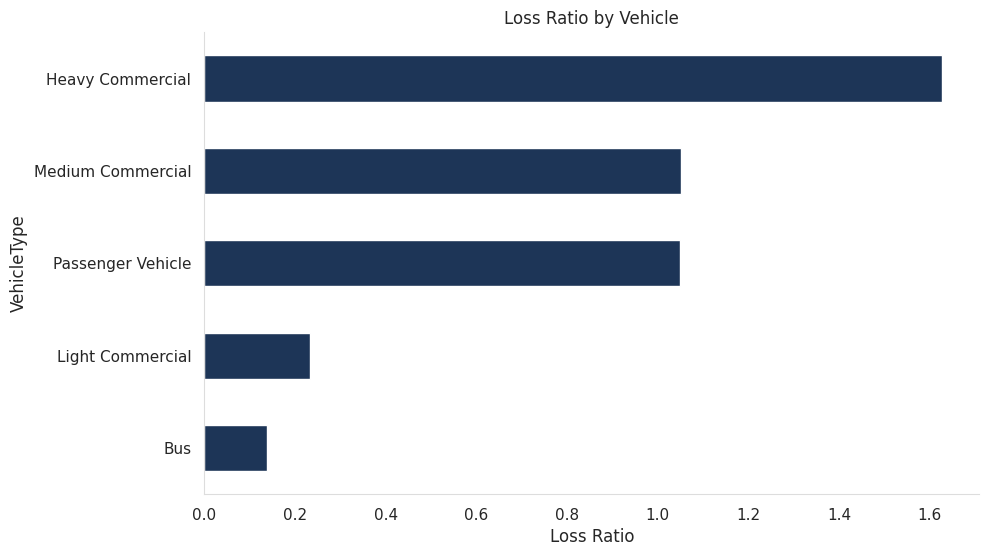

In [87]:
vehicle_lr['LossRatio'].sort_values().plot(
    kind='barh',
    figsize=(10,6)
)
plt.title('Loss Ratio by Vehicle')
plt.xlabel('Loss Ratio')
plt.show()

### Loss Ratio by Gender

In [75]:
gender_lr = df.groupby('Gender').agg({
    'TotalClaims': 'sum',
    'TotalPremium': 'sum'
})

gender_lr['LossRatio'] = (
    gender_lr['TotalClaims'] /
    gender_lr['TotalPremium']
)

gender_lr

,TotalClaims,TotalPremium,LossRatio
Gender,,,
Female,2.502461e+05,3.044806e+05,0.821879
Male,1.396704e+06,1.580143e+06,0.883910
Not specified,6.266391e+07,5.945983e+07,1.053886


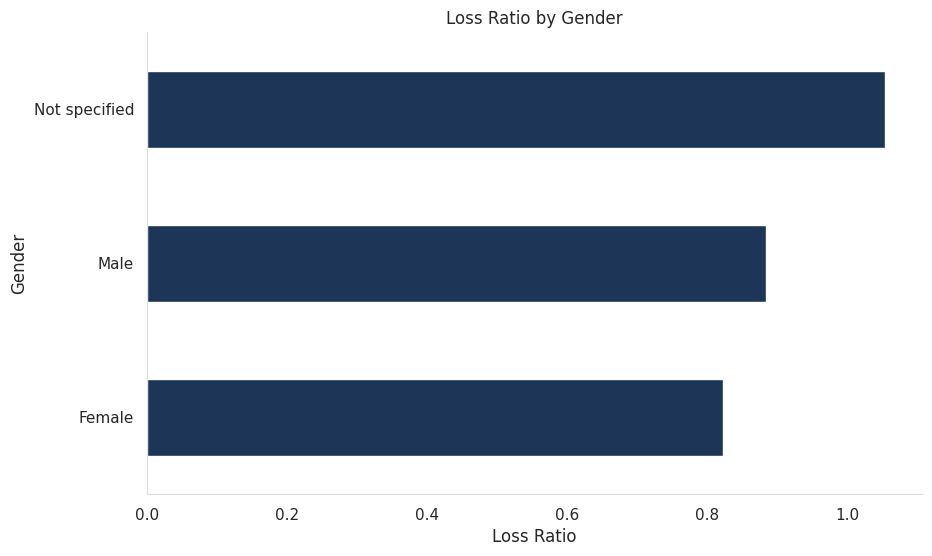

In [88]:
gender_lr['LossRatio'].sort_values().plot(
    kind='barh',
    figsize=(10,6)
)
plt.title('Loss Ratio by Gender')
plt.xlabel('Loss Ratio')
plt.show()

## 2. Distribution of Key Financial Variables

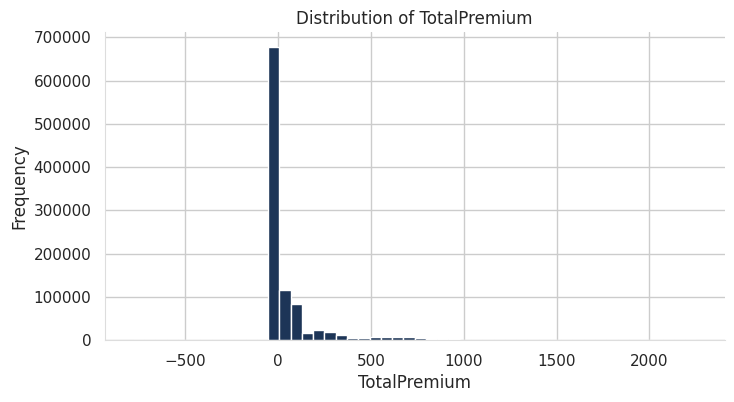

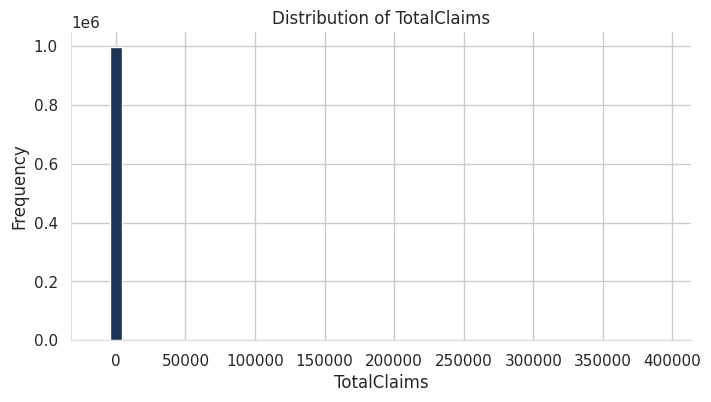

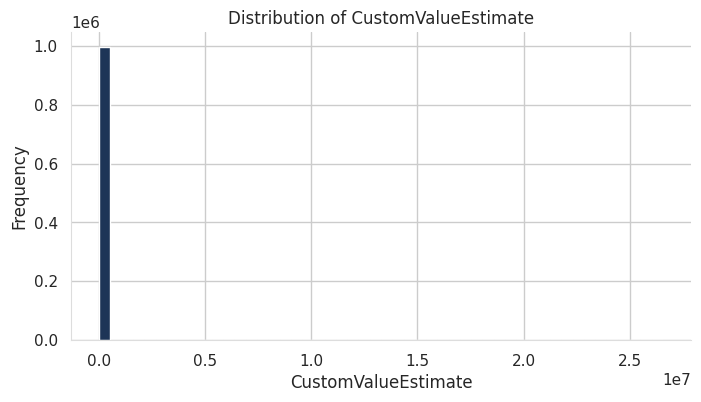

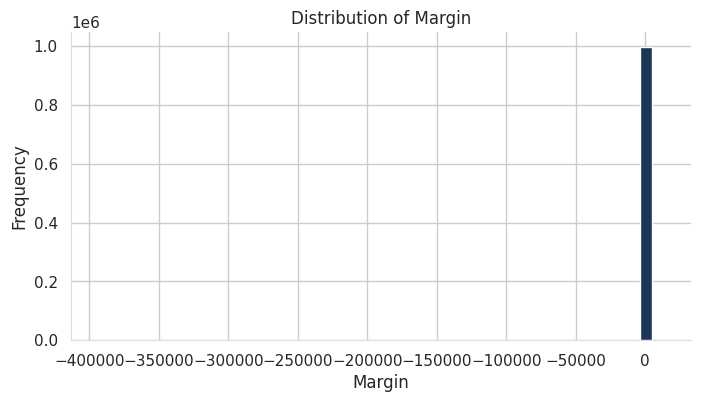

In [89]:
financial_cols = [
    'TotalPremium',
    'TotalClaims',
    'CustomValueEstimate',
    'Margin'
]

for col in financial_cols:
    plt.figure(figsize=(8,4))
    df[col].hist(bins=50)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

### Detecting Outliers

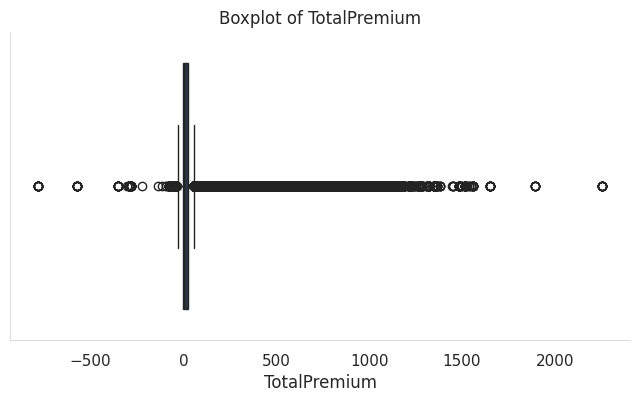

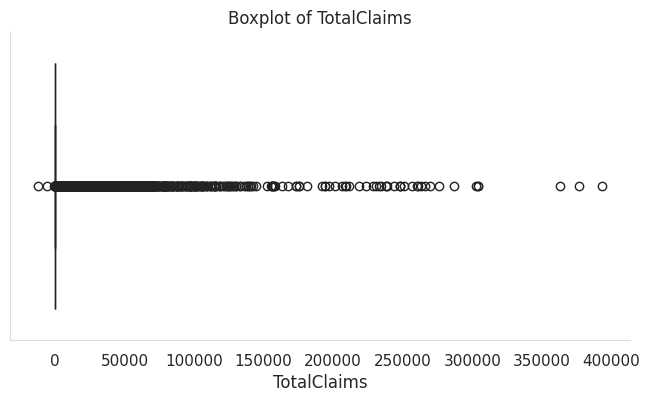

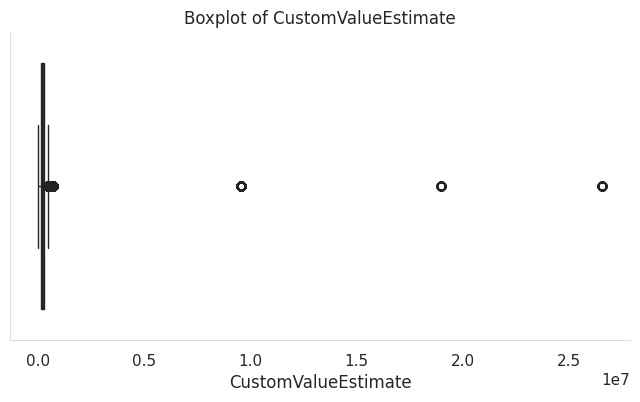

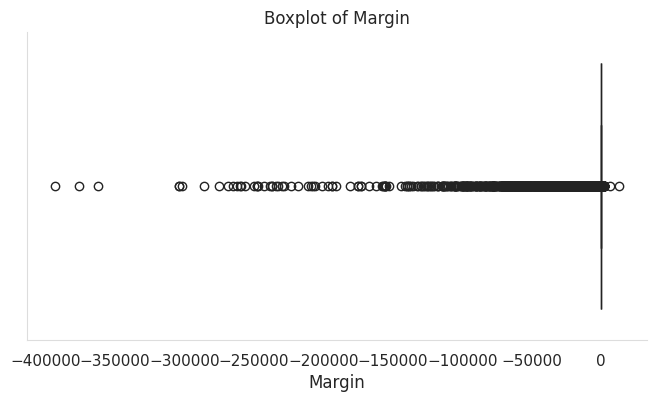

In [90]:
for col in financial_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### Statistical Outlier Check

In [91]:
Q1 = df['TotalClaims'].quantile(0.25)
Q3 = df['TotalClaims'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df['TotalClaims'] < Q1 - 1.5 * IQR) |
    (df['TotalClaims'] > Q3 + 1.5 * IQR)
]

print(outliers.shape)

(2780, 52)


## 3. Temporal Trends Over 18 Months

### Create Time Features

In [92]:
df['YearMonth'] = df['TransactionMonth'].dt.to_period('M')

### Claim Frequency Over Time

In [93]:
claim_frequency = df.groupby('YearMonth').apply(
    lambda x: (x['TotalClaims'] > 0).sum()
)

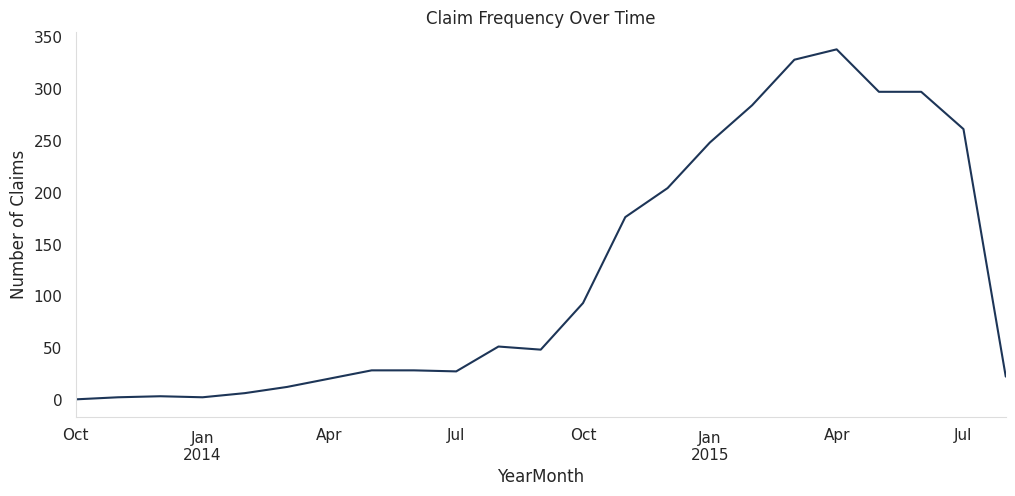

In [94]:
claim_frequency.plot(figsize=(12,5))
plt.title('Claim Frequency Over Time')
plt.ylabel('Number of Claims')
plt.show()

### Claim Severity Over Time

In [95]:
severity = df[df['TotalClaims'] > 0].groupby(
    'YearMonth'
)['TotalClaims'].mean()

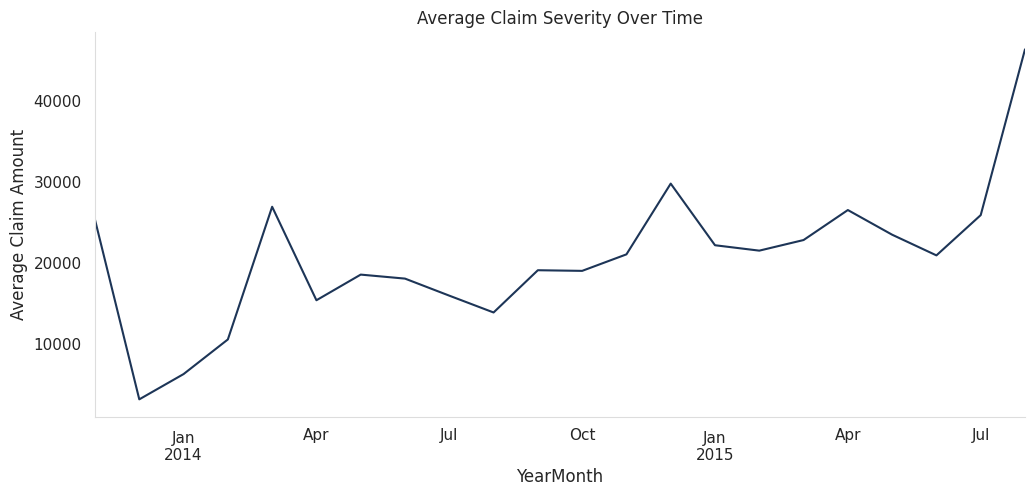

In [96]:
severity.plot(figsize=(12,5))
plt.title('Average Claim Severity Over Time')
plt.ylabel('Average Claim Amount')
plt.show()

### Premium Trends

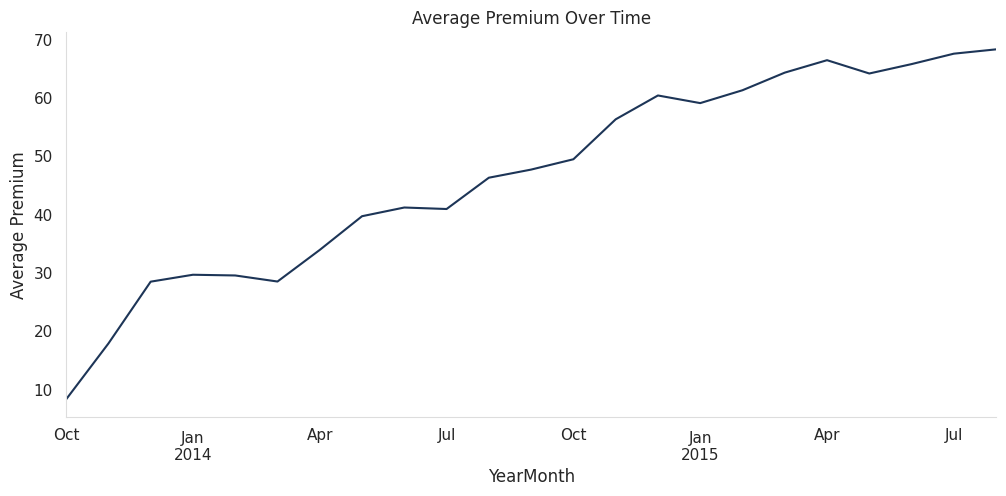

In [97]:
premium_trend = df.groupby('YearMonth')[
    'TotalPremium'
].mean()

premium_trend.plot(figsize=(12,5))
plt.title('Average Premium Over Time')
plt.ylabel('Average Premium')
plt.show()

## 4. Vehicle Makes/Models with Highest and Lowest Claims

### Average Claims by Make

In [99]:
make_claims = df.groupby('make')['TotalClaims'].mean()

highest_makes = make_claims.sort_values(
    ascending=False
).head(10)

lowest_makes = make_claims.sort_values().head(10)
lowest_makes

make
CITROEN                                0.0
CHERY                                  0.0
FORD                                   0.0
DAIHATSU                               0.0
GEELY                                  0.0
HINO                                   0.0
HUMMER                                 0.0
HONDA                                  0.0
JINBEI                                 0.0
KIA                                    0.0
Name: TotalClaims, dtype: float64

### Average Claims by Model

In [100]:
model_claims = df.groupby('Model')['TotalClaims'].mean()

highest_models = model_claims.sort_values(
    ascending=False
).head(10)

lowest_models = model_claims.sort_values().head(10)

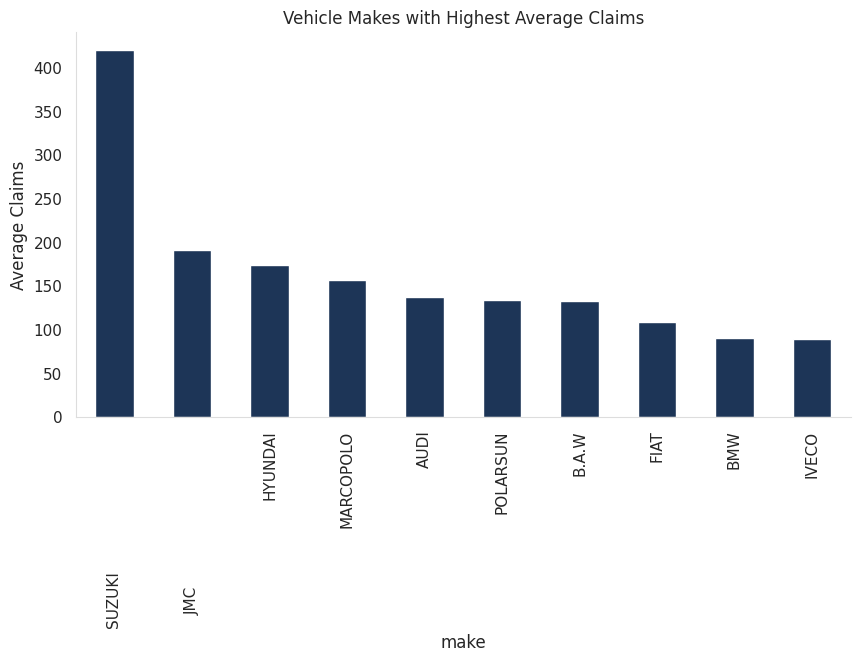

In [101]:
highest_makes.plot(kind='bar', figsize=(10,5))
plt.title('Vehicle Makes with Highest Average Claims')
plt.ylabel('Average Claims')
plt.show()

## Save data

In [ ]:
df.to_csv('data/insurance_cleaned.csv', index=False)